# Создание модели машинного обучения для предсказания снижения покупательской активности клиента в следующие три месяца

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов не эффективно, поэтому было принято решение сосредоточиться на повышении покупательской активности существующих клиентов за счёт персонализации предлагаемых им продуктов и услуг.

Основные задачи:

1) Необходимо классифицировать уровень финансовой активности постоянных клиентов по двум категориям: «прежний уровень» и «снизилась».

2) Нужно собрать данные по клиентам по следующим группам:
- признаки, которые описывают коммуникацию сотрудников компании с клиентом;
- признаки, которые описывают продуктовое поведение покупателя;
- признаки, которые описывают покупательское поведение клиента;
- признаки, которые описывают поведение покупателя на сайте. 

## Первичный анализ данных

In [1]:
!pip install optuna optuna-integration -q
!pip install phik -q
!pip install shap -q

In [2]:
#Импортируем все необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import phik
import warnings
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, 
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)
from optuna.integration import OptunaSearchCV
from optuna import distributions
from optuna.distributions import CategoricalDistribution

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#Загружаю необходимые файлы и сохраняю их в соответствующие датафреймы
market_df = pd.read_csv('/datasets/market_file.csv')
market_money_df = pd.read_csv('/datasets/market_money.csv')
market_time_df = pd.read_csv('/datasets/market_time.csv')
money_df = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')

In [4]:
#Вывожу первые 5 строк датафрейма 'market_df' и общую информацию о нем
display(market_df.head(5))
print(market_df.info())

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

**Вывод:** В датафрейме 'market_df' содержатся данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении. Всего в датафрейме 1300 значений и 13 параметров:
- id — номер покупателя в корпоративной базе данных;
- покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень»; 
- тип сервиса — уровень сервиса, например «премиум» и «стандарт»;
- разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель;
- маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента; 
- маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце;
- длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте;
- акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев;
- популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев;
- средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца;
- неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца;
- ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта;
- страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

Все столбцы имеют верный тип данных.

In [5]:
#Вывожу первые 5 строк датафрейма 'market_money_df' и общую информацию о нем
display(market_money_df.head(5))
print(market_money_df.info())

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB
None


**Вывод:** В датафрейме 'market_money_df' содержатся данные о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом. Всего в датафрейме 3900 значений и 3 параметра:
- id — номер покупателя в корпоративной базе данных;
- период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц';
- выручка — сумма выручки за период.

Все столбцы имеют верный тип данных.

In [6]:
#Вывожу первые 5 строк датафрейма 'market_time_df' и общую информацию о нем
display(market_time_df.head(5))
print(market_time_df.info())

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB
None


**Вывод:** В датафрейме 'market_time_df' содержатся данные о времени (в минутах), которое покупатель провёл на сайте в течение периода. Всего в датафрейме 2600 значений и 3 параметра:
- id — номер покупателя в корпоративной базе данных.
- период — название периода, во время которого зафиксировано общее время.
- минут — значение времени, проведённого на сайте, в минутах.

Все столбцы имеют верный тип данных.

In [7]:
#Вывожу первые 5 строк датафрейма 'money_df' и общую информацию о нем
display(money_df.head(5))
print(money_df.info())

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB
None


**Вывод:** В датафрейме 'money_df' содержатся данные о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю. Всего в датафрейме 1300 значений и 2 параметра:
- id — номер покупателя в корпоративной базе данных;
- прибыль — значение прибыли.
Все столбцы имеют верный тип данных.

## Предобработка данных

In [8]:
#Проверяю наличие пропущенных значений в датафреймах
print(market_df.isna().sum())
print(market_money_df.isna().sum())
print(market_time_df.isna().sum())
print(money_df.isna().sum())

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64
id         0
Период     0
Выручка    0
dtype: int64
id        0
Период    0
минут     0
dtype: int64
id         0
Прибыль    0
dtype: int64


**Вывод:** В датафреймах нет пропущенных значений.

In [9]:
#Проверяю наличие неявных дубликатов в датафрейме market_df
market_df_dub_check = ['Покупательская активность', 'Тип сервиса', 'Разрешить сообщать', 'Популярная_категория']
for c in market_df_dub_check:
    print(market_df[c].unique())
#Убираю неявный дубликат в датафрейме market_df
market_df['Тип сервиса'] = market_df['Тип сервиса'].str.replace('стандартт', 'стандарт')
#Исправляю ошибку в столбце 'Популярная_категория'
market_df['Популярная_категория'] = market_df['Популярная_категория'].str.replace('Косметика и аксесуары', 'Косметика и аксесcуары')

['Снизилась' 'Прежний уровень']
['премиум' 'стандартт' 'стандарт']
['да' 'нет']
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


**Вывод:** В датафрейме market_df был обнаружен неявный дубликат в столбце 'Тип сервиса', который был заменен соответствующим значением, а также исправлена ошибка в столбце 'Популярная_категория'.

In [10]:
#Проверяю наличие неявных дубликатов в столбце 'Период' датафрейма market_money_df
print(market_money_df['Период'].unique())
#Заменяю термин 'препредыдущий_месяц' на 'позапрошлый_месяц'
market_money_df['Период'] = market_money_df['Период'].str.replace('препредыдущий_месяц', 'позапрошлый_месяц')

['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


**Вывод:**  В датафрейме market_money_df представлены данные за 3 периода: позапрошлый, предыдущий и текущий месяцы.

In [11]:
#Проверяю наличие неявных дубликатов в столбце 'Период' датафрейма market_time_df
print(market_time_df['Период'].unique())
#Убираю ошибку в столбце 'Период' датафрейма market_time_df
market_time_df['Период'] = market_time_df['Период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

['текущий_месяц' 'предыдцщий_месяц']


**Вывод:** В датафрейме market_time_df была обнаружена и исправлена ошибка в столбце 'Период'.

In [12]:
#Проверяю наличие неявных дубликатов в датафреймах 
print('Кол-во явных дубликатов в market_df', market_df.duplicated(subset=['id','Тип сервиса']).sum())
print('Кол-во явных дубликатов в market_money_df', market_money_df.duplicated(subset=['id','Период']).sum())
print('Кол-во явных дубликатов в market_time_df', market_time_df.duplicated(subset=['id','Период']).sum())
print('Кол-во явных дубликатов в money_df', money_df.duplicated(subset=['id']).sum())
#На текущих данных нет явных дубликатов, но оставляю для надёжности
market_df = market_df.drop_duplicates()
market_money_df = market_money_df.drop_duplicates()
market_time_df = market_time_df.drop_duplicates()
money_df = money_df.drop_duplicates()

Кол-во явных дубликатов в market_df 0
Кол-во явных дубликатов в market_money_df 0
Кол-во явных дубликатов в market_time_df 0
Кол-во явных дубликатов в money_df 0


**Вывод:** В датафреймах были удалены явные и неявные дубликаты.

**Общий вывод:** Была проведена предобработка данных, в ходе чего неявные дубликаты в столбце 'Период' в датафреймах market_money_df и market_time_df были заменены на соответствующие значения, а явные дубликаты в датафрейме market_money_df были удалены. 

##  Исследовательский анализ данных

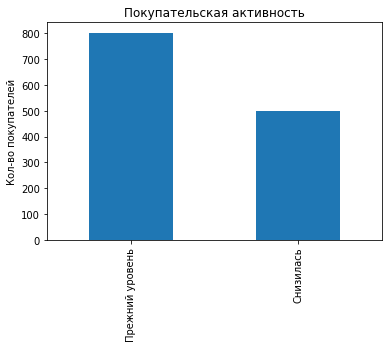

In [13]:
#Строю столбчатую диаграмму для параметра 'Покупательская активность' в датафрейме market_df
market_df['Покупательская активность'].value_counts().plot(kind='bar');
plt.title('Покупательская активность')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** Согласно диаграмме, большинство клиентов сохранили прежний уровень покупательской активности — таких наблюдений около 800. Количество клиентов с снизившейся активностью составляет примерно 500, что почти в два раза меньше.

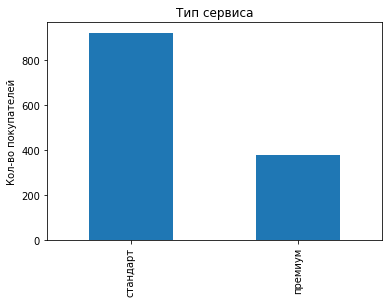

In [14]:
#Строю столбчатую диаграмму для параметра 'Покупательская активность' в датафрейме market_df
market_df['Тип сервиса'].value_counts().plot(kind='bar');
plt.title('Тип сервиса')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** По диаграмме видно, что количество покупателей с типом сервиса стандарт более чем в два раза больше покупателей с типом сервиса премиум.

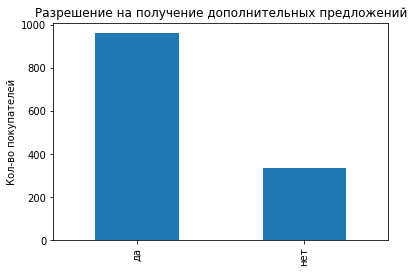

In [15]:
#Строю столбчатую диаграмму для параметра 'Разрешить сообщать' в датафрейме market_df
market_df['Разрешить сообщать'].value_counts().plot(kind='bar');
plt.title('Разрешение на получение дополнительных предложений')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** По диаграмме видно, что в основном покупатели дают согласие на получение дополнительных предложений о товаре.

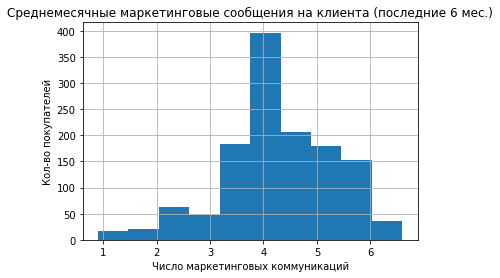

In [16]:
#Строю гистограмму для параметра 'Маркет_актив_6_мес' в датафрейме market_df
market_df['Маркет_актив_6_мес'].hist();
plt.title('Среднемесячные маркетинговые сообщения на клиента (последние 6 мес.)')
plt.xlabel('Число маркетинговых коммуникаций')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** На гистограмме видно, что среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев распределено в интервале от 0.5 до 7, с явным пиком в районе значения 4. Кроме того, стоит отметить, что большинство наблюдений находится в промежутке от 3 до 6.

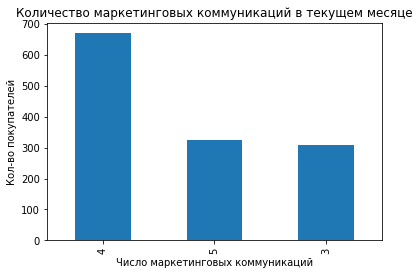

In [17]:
#Строю столбчатую диаграмму для параметра 'Маркет_актив_тек_мес' в датафрейме market_df
market_df['Маркет_актив_тек_мес'].value_counts().plot(kind='bar');
plt.title('Количество маркетинговых коммуникаций в текущем месяце')
plt.xlabel('Число маркетинговых коммуникаций')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** Диаграмма показывает, что количество маркетинговых коммуникаций в текущем месяце принимает три значения: 3, 4 и 5. Наибольшее количество наблюдений было отмечено для значения 4, тогда как значения 3 и 5 встречаются примерно с одинаковой частотой.

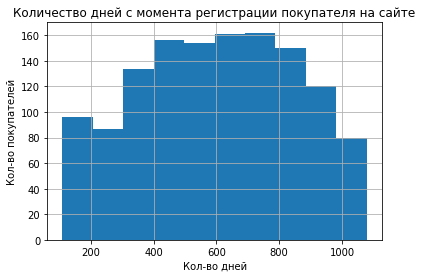

In [18]:
#Строю гистограмму для параметра 'Длительность' в датафрейме market_df
market_df['Длительность'].hist();
plt.title('Количество дней с момента регистрации покупателя на сайте')
plt.xlabel('Кол-во дней')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** Гистограмма показывает, что количество дней прошедших с момента регистрации покупателя на сайте распределено в интервале от 50 до 1200, c наибольшим количеством значений в интервале от 400 до 800.

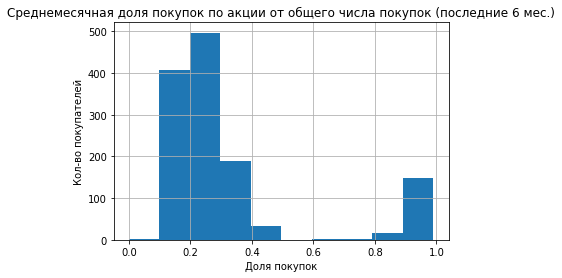

In [19]:
#Строю гистограмму для параметра 'Акционные_покупки' в датафрейме market_df
market_df['Акционные_покупки'].hist();
plt.title('Cреднемесячная доля покупок по акции от общего числа покупок (последние 6 мес.)')
plt.xlabel('Доля покупок')
plt.ylabel('Кол-во покупателей')
plt.show()

**Вывод:** На гистограмме показано, что среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев сосредоточена в пределах от 0.1 до 0.5, с пиком в районе от 0.2 до 0.3. Кроме того, стоит отметить, что примерно в три раза меньше значений наблюдается в районе от 0.8 до 1.0.

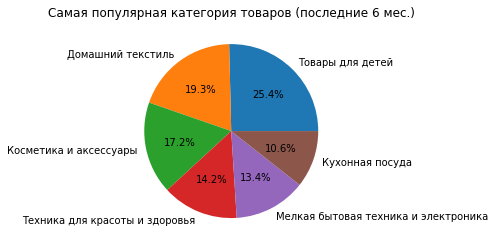

In [20]:
#Строю круговую диаграмму для параметра 'Популярная_категория' в датафрейме market_df
market_df['Популярная_категория'].value_counts().plot(kind='pie', label='', autopct='%1.1f%%');
plt.title('Cамая популярная категория товаров (последние 6 мес.)')
plt.show()

Text(0, 0.5, 'Кол-во покупателей')

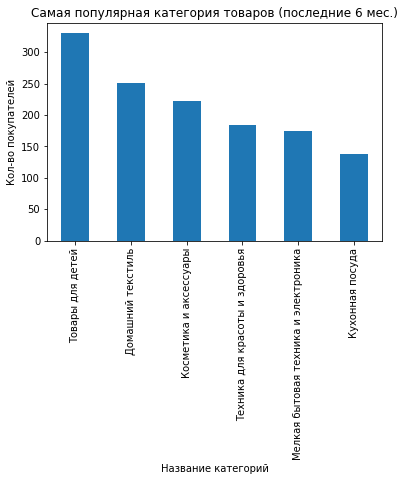

In [21]:
#Строю столбчатую диаграмму для параметра 'Популярная_категория' в датафрейме market_df
market_df['Популярная_категория'].value_counts().plot(kind='bar');
plt.title('Cамая популярная категория товаров (последние 6 мес.)')
plt.xlabel('Название категорий')
plt.ylabel('Кол-во покупателей')

**Вывод:** На первом по популярности месте находится категория 'Товары для детей', которая составляет четверь от всех категорий (25.4%), на втором - 'Домашний текстиль' (19.3%), на третьем - Косметика и аксесуары (17.2%). Более маленькие доли занимают 'Техника для красоты и здоровья'(14.2%), 'Мелкая бытовая техника и электроника' (13.4%), 'Кухонная посуда' (10.6%).

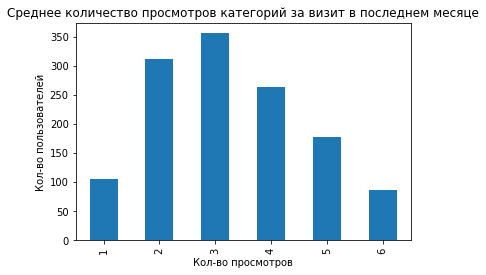

In [22]:
#Строю столбчатую диаграмму для параметра 'Средний_просмотр_категорий_за_визит' в датафрейме market_df и сортирую значения признака по возрастанию
market_df['Средний_просмотр_категорий_за_визит'].value_counts().sort_index().plot(kind='bar');
plt.title('Среднее количество просмотров категорий за визит в последнем месяце')
plt.xlabel('Кол-во просмотров')
plt.ylabel('Кол-во пользователей')
plt.show()

In [23]:
#Проверяю данные для параметра 'Средний_просмотр_категорий_за_визит' в датафрейме market_df на нормальность
stat, p = shapiro(market_df['Средний_просмотр_категорий_за_визит'])
if p < 0.05:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

Распределение не нормальное


**Вывод:** Распределение среднего числа категорий, просмотренных покупателем за визит в течение последнего месяца, не нормальное и имеет максимум около значения 3.

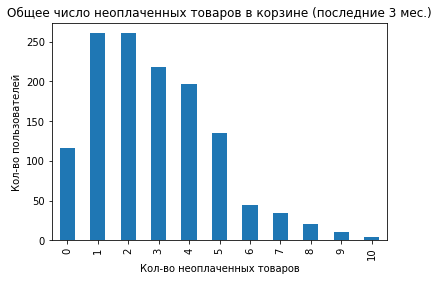

In [24]:
#Строю столбчатую диаграмму для параметра 'Неоплаченные_продукты_штук_квартал' в датафрейме market_df и сортирую значения признака по возрастанию
market_df['Неоплаченные_продукты_штук_квартал'].value_counts().sort_index().plot(kind='bar');
plt.title('Общее число неоплаченных товаров в корзине (последние 3 мес.)')
plt.xlabel('Кол-во неоплаченных товаров')
plt.ylabel('Кол-во пользователей')
plt.show()

**Вывод:** Распределение общего количества неоплаченных товаров в корзине за последние 3 месяца имеет положительную скошенность, с максимумом в районе значений 1 и 2.

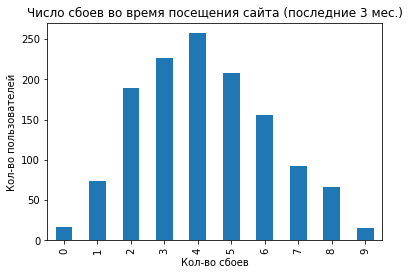

In [25]:
#Строю столбчатую диаграмму для параметра 'Ошибка_сервиса' в датафрейме market_df и сортирую значения признака по возрастанию
market_df['Ошибка_сервиса'].value_counts().sort_index().plot(kind='bar');
plt.title('Число сбоев во время посещения сайта (последние 3 мес.)')
plt.xlabel('Кол-во сбоев')
plt.ylabel('Кол-во пользователей')
plt.show()

In [26]:
#Проверяю данные для параметра 'Ошибка_сервиса' в датафрейме market_df на нормальность
stat, p = shapiro(market_df['Ошибка_сервиса'])
if p < 0.05:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

Распределение не нормальное


**Вывод:** Распределение числа сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца, не нормальное, с максимумом у значения 4.

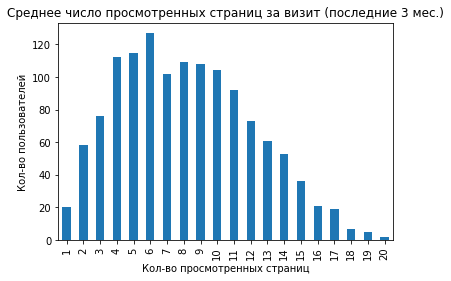

In [27]:
#Строю столбчатую диаграмму для параметра 'Страниц_за_визит' в датафрейме market_df и сортирую значения признака по возрастанию
market_df['Страниц_за_визит'].value_counts().sort_index().plot(kind='bar');
plt.title('Среднее число просмотренных страниц за визит (последние 3 мес.)')
plt.xlabel('Кол-во просмотренных страниц')
plt.ylabel('Кол-во пользователей')
plt.show()

**Вывод:** Распределение среднего количества страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца, правосторонне асимметричное с максимумом в районе значений 4-6.

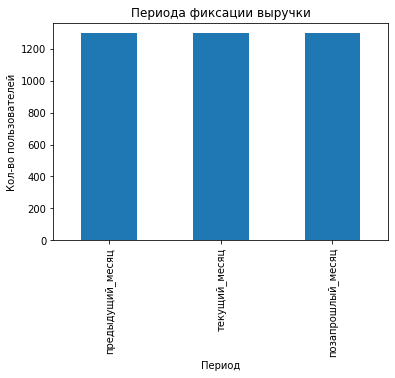

In [28]:
#Строю столбчатую диаграмму для параметра 'Период' в датафрейме market_money_df
market_money_df['Период'].value_counts().plot(kind='bar');
plt.title('Периода фиксации выручки')
plt.xlabel('Период')
plt.ylabel('Кол-во пользователей')
plt.show()

**Вывод:** Число пользователей, для которых зафиксировали выручку, остаётся стабильным в течение последних трёх месяцев. 

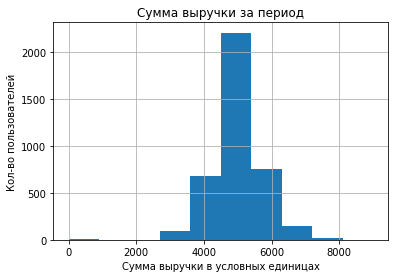

In [29]:
#Строю столбчатую диаграмму для параметра 'Выручка' в датафрейме market_money_df
market_money_df['Выручка'].hist(range=(0, 9000));
plt.title('Сумма выручки за период')
plt.xlabel('Сумма выручки в условных единицах')
plt.ylabel('Кол-во пользователей')
plt.show()

**Вывод:** Основная часть выручки на одного покупателя сосредоточена в интервале от 2 500 до 8 000, при этом наибольшее количество наблюдений приходится на значение около 5 000.

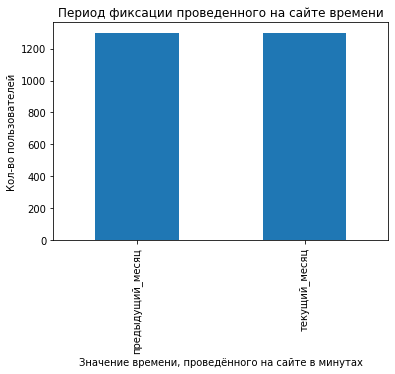

In [30]:
#Строю столбчатую диаграмму для параметра 'Период' в датафрейме market_time_df
market_time_df['Период'].value_counts().plot(kind='bar');
plt.title('Период фиксации проведенного на сайте времени')
plt.xlabel('Значение времени, проведённого на сайте в минутах')
plt.ylabel('Кол-во пользователей')
plt.show()

**Вывод:** Для предыдущего и текущего месяцев было зафиксировано примерно одинаковое количество значений общего времени пребывания на сайте.

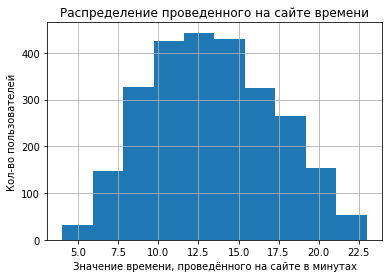

In [31]:
#Строю столбчатую диаграмму для параметра 'минут' в датафрейме market_time_df
market_time_df['минут'].hist();
plt.title('Распределение проведенного на сайте времени')
plt.xlabel('Значение времени, проведённого на сайте в минутах')
plt.ylabel('Кол-во пользователей')
plt.show()

In [32]:
#Проверяю данные для параметра 'минут' в датафрейме market_time_df на нормальность
stat, p = shapiro(market_time_df['минут'])
if p < 0.05:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

Распределение не нормальное


**Вывод:** Распределение значения времени пребывания на сайте не нормальное, с пиком у значения 12.5.

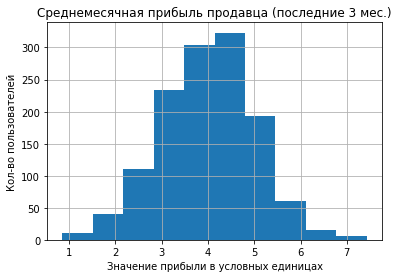

In [33]:
#Строю столбчатую диаграмму для параметра 'Прибыль' в датафрейме money_df
money_df['Прибыль'].hist();
plt.title('Среднемесячная прибыль продавца (последние 3 мес.)')
plt.xlabel('Значение прибыли в условных единицах')
plt.ylabel('Кол-во пользователей')
plt.show()

In [34]:
#Проверяю данные для параметра 'Прибыль' в датафрейме money_df на нормальность
stat, p = shapiro(money_df['Прибыль'])
if p < 0.05:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

Распределение нормальное


**Вывод:** Распределение значения прибыли нормальное, с пиком у значений 3.5 - 5.

**Общий вывод:**  В ходе проведенного исследовательского анализа было установлено, что большинство клиентов сохранили прежний уровень покупательской активности — таких почти в два раза больше, чем тех, у кого активность снизилась. Среди типов сервиса доминирует стандартный, а большинство пользователей дают согласие на получение маркетинговых предложений.

Маркетинговые коммуникации на одного покупателя за 6 месяцев в основном варьируются от 3 до 6, с пиком на значении 4. Аналогичное распределение наблюдается и в текущем месяце. Количество записей по времени, проведённому на сайте, примерно одинаково в текущем и предыдущем месяцах, а само время распределено не нормальное с максимумом около 12.5 минут. Распределение среднемесячной прибыли продавца за последние 3 месяца нормальное с пиком у значений 3.5-5.

Поведенческие характеристики также демонстрируют стабильность: просмотры категорий и сбоев — близки к нормальному распределению, просмотры страниц — скошены вправо. Число пользователей, для которых зафиксировали выручку, остаётся стабильным в течение последних трёх месяцев, а значения выручки сосредоточены в диапазоне от 2 500 до 8 000, с пиком около 5 000.

Наиболее популярные товарные категории — «Товары для детей», «Домашний текстиль» и «Косметика и аксессуары».

##  Объединение данных в единый датасет

In [35]:
#Разделяю данные о выручке на отдельные столбцы для каждого периода
pivoted_market_money_df = market_money_df.pivot_table(index='id', columns='Период', values='Выручка')
pivoted_market_money_df.columns = [f"Выручка_{c}" for c in pivoted_market_money_df.columns]
#Разделяю данные о времени пребывания на сайте на отдельные столбцы для каждого периода
pivoted_market_time_df = market_time_df.pivot_table(index='id', columns='Период', values='минут')
pivoted_market_time_df.columns = [f"минут_{k}" for k in pivoted_market_time_df.columns ]

In [36]:
#Вывожу размерности датавреймов до объединения
print(market_df.shape)
print(pivoted_market_money_df.shape)
print(pivoted_market_time_df.shape)
#Объединяю таблицы 
merged_df = pd.merge(market_df, pivoted_market_money_df, on='id', how='outer')
fin_merged_df = pd.merge(merged_df, pivoted_market_time_df, on='id', how='outer')
display(fin_merged_df)
#Вывожу размерность конечного датафрейма
print(fin_merged_df.shape)

(1300, 13)
(1300, 3)
(1300, 2)


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_позапрошлый_месяц,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,0.0,0.0,3293.1,13,14
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7
1296,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,5299.0,4729.0,5353.0,12,11
1297,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5334.0,5160.0,5139.2,12,18
1298,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7


(1300, 18)


In [37]:
#Фильтрую финальный датафрейм на наличие неактивных покупателей
non_active_clients = fin_merged_df.loc[(fin_merged_df['Выручка_позапрошлый_месяц'] == 0) & (fin_merged_df['Выручка_предыдущий_месяц'] == 0) & (fin_merged_df['Выручка_текущий_месяц'] == 0)]
print(non_active_clients.shape)

(0, 18)


**Вывод:** За последние три месяца не выявлено клиентов без покупательской активности — каждый клиент совершал хотя бы одну покупку в течение этого периода.

##  Корреляционный анализ

In [38]:
display(fin_merged_df)

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_позапрошлый_месяц,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,0.0,0.0,3293.1,13,14
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,4704.0,3664.0,4741.7,14,7
1296,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,5299.0,4729.0,5353.0,12,11
1297,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5334.0,5160.0,5139.2,12,18
1298,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4725.0,4923.0,5224.6,18,7


In [39]:
print(fin_merged_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1300 entries, 0 to 1299
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

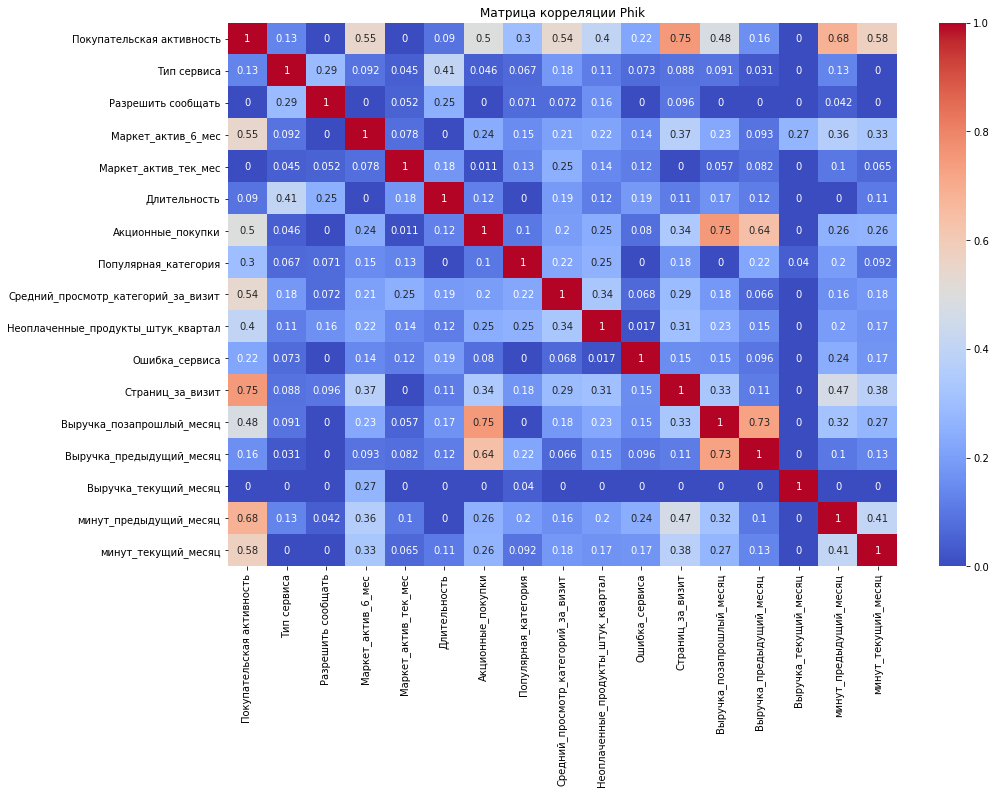

In [40]:
#Строю матрицу корреляции Phik 
plt.figure(figsize=(15, 10))
corr_matrix = fin_merged_df.drop(columns='id').phik_matrix(interval_cols = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Выручка_позапрошлый_месяц', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц'])
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции Phik')
plt.show()

**Вывод:** На основе рассчитанной корреляционной матрицы можно выделить признаки с высокой степенью взаимосвязи:

- Сильная корреляция (|r| ≥ 0.7): \
1) 'Cтраниц_за_визит' и 'Покупательская активность' (0.75), \
2) 'Выручка_позапрошлый_месяц' и 'Акционные_покупки' (0.75), \
3) 'Выручка_предыдущий_месяц' и 'Выручка_позапрошлый_месяц'(0.73);

- Заметная корреляция (0.5 ≤ |r| < 0.7): \
1) 'минут_предыдущий_месяц' и 'Покупательская активность' (0.68), \
2) 'минут_текущий_месяц' и 'Покупательская активность' (0.58), \
3) 'Выручка_предыдущий_месяц' и 'Акционные_покупки' (0.64).

In [41]:
#Делаю VIF анализ для проверки на мультиколлинеарность
num_features =  ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит','Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'Выручка_позапрошлый_месяц', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц','минут_предыдущий_месяц', 'минут_текущий_месяц']
vif_const = add_constant(fin_merged_df[num_features])
vif_df = pd.DataFrame()
vif_df["feature"] = vif_const.columns
vif_df["VIF"] = [variance_inflation_factor(vif_const.values, i) for i in range(vif_const.shape[1])]
print(vif_df)

                                feature         VIF
0                                 const  237.934594
1                    Маркет_актив_6_мес    1.214885
2                  Маркет_актив_тек_мес    1.049014
3                          Длительность    1.096925
4                     Акционные_покупки    1.185291
5   Средний_просмотр_категорий_за_визит    1.178125
6    Неоплаченные_продукты_штук_квартал    1.183844
7                        Ошибка_сервиса    1.076985
8                      Страниц_за_визит    1.397622
9             Выручка_позапрошлый_месяц    1.575942
10             Выручка_предыдущий_месяц    1.442299
11                Выручка_текущий_месяц    1.093738
12               минут_предыдущий_месяц    1.506574
13                  минут_текущий_месяц    1.290888


**Вывод:** По результатам расчёта VIF, все признаки имеют допустимый уровень линейной зависимости (VIF < 5), что указывает на отсутствие мультиколлинеарности.

##  Выбор лучшей модели для предсказания снижения покупательской способности

In [42]:
#Проверяю наличие дисбаланса классов
print(fin_merged_df['Покупательская активность'].unique())
print(fin_merged_df['Покупательская активность'].value_counts(normalize=True))

['Снизилась' 'Прежний уровень']
Прежний уровень    0.616923
Снизилась          0.383077
Name: Покупательская активность, dtype: float64


**Вывод:** В целевой переменной наблюдается умеренный дисбаланс классов (Прежний уровень — 61.7%, Снизилась — 38.3%).
Поскольку задача сводится к предсказанию изменения покупательской активности, наиболее подходящей метрикой оценки качества модели является ROC AUC, так как она учитывает как чувствительность (recall), так и специфичность (specificity), и остаётся устойчивой к дисбалансу классов.

In [43]:
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Выделяю в отдельные переменные целевой признак и входные признаки, исключив столбец 'id'
X = fin_merged_df.drop(columns=['id', 'Покупательская активность'])
y = fin_merged_df['Покупательская активность']

#Разделяю данные на тренировочные и тестовые, фиксирую при этом random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

#Проверяю размерности получившихся df
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

#Создаю списки категориальных и количественных признаков тренировочной выборки
ohe_columns = ['Разрешить сообщать', 'Популярная_категория']
ord_columns = ['Тип сервиса']
num_columns = ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']

#Создаю пайплайн для подготовки признаков из списка ohe_columns через заполнение пропусков и OHE-кодирование 
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe',
             OneHotEncoder(handle_unknown='ignore', sparse=False)
        )
    ]
)

#Создаю пайплайн для подготовки из списка ord_columns через заполнение пропусков и Ordinal-кодирование
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder( 
                categories=[['стандарт', 'премиум']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

#Создаю общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

#Создаю итоговый пайплайн через подготовку данных и модели 
pipe_final= Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

#Создаю словарь с гиперпараметрами для перебора в GridSearchCV и RandomizedSearchCV
param = {
    'preprocessor__num': [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    'models':[
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        KNeighborsClassifier(),
        SVC(random_state=RANDOM_STATE, probability=True),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ]
}

#Создаю словарь с гиперпараметрами для перебора в OptunaSearchCV
optuna_param = {
    'preprocessor__num': CategoricalDistribution([
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ]),
    'models': CategoricalDistribution([
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        KNeighborsClassifier(),
        SVC(probability=True, random_state=RANDOM_STATE),  # обязательно probability=True
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ])
}

#Ищу лучшие гиперпараметры и модель через GridSearchCV
grid = GridSearchCV(
    pipe_final, 
    param_grid=param, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)
grid.fit(X_train, y_train)

#Ищу лучшие гиперпараметры и модель через RandomizedSearchCV
rs = RandomizedSearchCV(
    pipe_final, 
    param, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

rs.fit(X_train, y_train)

#Ищу лучшие гиперпараметры и модель через OptunaSearchCV
oscv = OptunaSearchCV(
    pipe_final, 
    optuna_param, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

oscv.fit(X_train, y_train)

#Вывожу параметры лучшей модели при разных стратегиях подбора гиперпараметров
print('Лучшая модель и её параметры при GridSearchCV:\n\n', grid.best_estimator_, grid.best_score_)
print('Лучшая модель и её параметры при RandomizedSearchCV:\n\n', rs.best_estimator_, rs.best_score_)
print('Лучшая модель и её параметры при OptunaSearchCV:\n\n', oscv.best_estimator_, oscv.best_score_)

(975, 16) (325, 16) (975,) (325,)


/opt/conda/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains StandardScaler() which is of type StandardScaler.
  optuna_warn(message)
/opt/conda/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains MinMaxScaler() which is of type MinMaxScaler.
  optuna_warn(message)
/opt/conda/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains RobustScaler() which is of type RobustScaler.
  optuna_warn(message)
/opt/conda/lib/python3.9/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float a

Лучшая модель и её параметры при GridSearchCV:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Разрешить сообщать',
                                                   'Популярная_категория']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                       

**Вывод:** По результатам подбора гиперпараметров с использованием различных стратегий (GridSearchCV, RandomizedSearchCV, OptunaSearchCV), было установлено, что итоговая производительность модели не зависит от выбранного метода поиска. Во всех случаях наилучшие результаты продемонстрировала модель LogisticRegression с параметром random_state=42.

In [44]:
# Предсказания для тестовой выборки с использованием лучшей модели
best_model = rs.best_estimator_

# Предсказываем классы и вероятности
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]  #Вероятность того, что покупательская активность снизилась

# Сохраняем в датафрейм для дальнейшего анализа
X_test_pred = X_test.copy()
X_test_pred['Истинные значения'] = y_test.values
X_test_pred['Предсказанные значения'] = y_pred
X_test_pred['Вероятность снижения покупательской активности'] = y_proba

display(X_test_pred)

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_позапрошлый_месяц,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,Истинные значения,Предсказанные значения,Вероятность снижения покупательской активности
478,стандарт,да,4.6,4,177,0.24,Косметика и аксесcуары,3,2,7,14,5073.0,4999.0,5192.7,17,20,Снизилась,Прежний уровень,0.023064
721,стандарт,да,5.5,4,1052,0.24,Домашний текстиль,2,3,6,17,4959.0,5217.0,5570.6,18,11,Прежний уровень,Прежний уровень,0.056184
312,стандарт,да,4.0,5,618,0.39,Товары для детей,2,4,5,2,4532.0,3299.0,3328.9,6,12,Снизилась,Снизилась,0.975026
660,стандарт,да,6.1,4,953,0.26,Домашний текстиль,5,2,5,10,4999.0,5690.5,6419.8,8,8,Прежний уровень,Прежний уровень,0.217167
823,стандарт,да,4.7,5,508,0.23,Косметика и аксесcуары,4,3,5,6,4906.0,5039.5,5285.2,15,12,Прежний уровень,Прежний уровень,0.265020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,стандарт,да,5.5,3,868,0.14,Товары для детей,3,2,6,11,5276.0,5766.0,5468.3,20,16,Прежний уровень,Прежний уровень,0.019636
526,стандарт,да,4.1,5,626,0.15,Техника для красоты и здоровья,4,2,4,16,5173.0,3753.0,5111.5,14,13,Прежний уровень,Прежний уровень,0.028430
715,премиум,да,5.2,4,982,0.28,Техника для красоты и здоровья,2,2,4,12,4479.0,4074.0,4555.0,15,22,Прежний уровень,Прежний уровень,0.075606
665,стандарт,нет,6.1,3,312,0.47,Домашний текстиль,3,1,2,12,5518.0,5324.5,5286.8,13,13,Прежний уровень,Прежний уровень,0.110639


##  Анализ важности признаков

  0%|          | 0/50 [00:00<?, ?it/s]

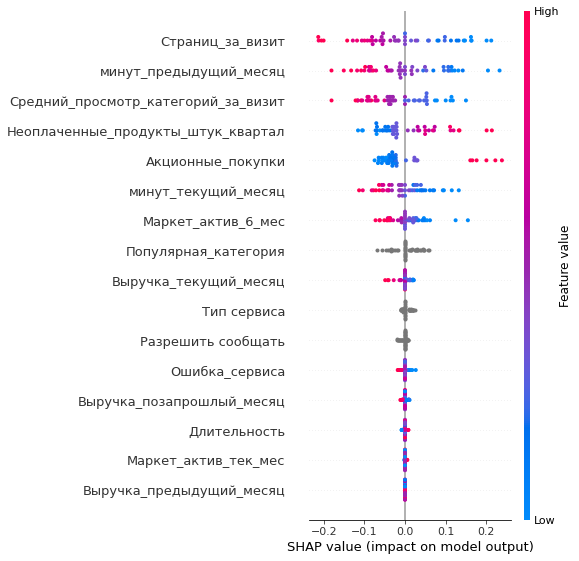

In [45]:
predict_fn = lambda x: best_model.predict_proba(pd.DataFrame(x, columns=X_train.columns))
X_background = X_train.sample(100, random_state=42)
explainer = shap.KernelExplainer(predict_fn, X_background)
X_to_explain = X_train.sample(50, random_state=42)
shap_values = explainer(X_to_explain)
#shap.plots.beeswarm(shap_values[:, :, 1], max_display=17)
shap.summary_plot(shap_values[:, :, 1], X_to_explain, max_display=17)

**Вывод:**  По графику SHAP-важности признаков видно, что наибольший вклад в предсказание снижения покупательской активности вносят следующие признаки:
- Страниц_за_визит
- минут_предыдущий_месяц
- Средний_просмотр_категорий_за_визит
- Неоплаченные_продукты_штук_квартал
- Акционные_покупки.

При этом:
- Высокие значения признаков 'Страниц_за_визит', 'минут_предыдущий_месяц' и ' Средний_просмотр_категорий_за_визит' уменьшают вероятность снижения активности — такие пользователи, как правило, остаются активными. Пользователи с высокими значениями по этим признакам - лояльные, которые скорее всего составляют основную базу клиентов на сайте.
- Напротив, высокие значения признаков 'Акционные_покупки' и 'Неоплаченные_продукты_штук_квартал' повышают вероятность снижения активности — такие клиенты чаще попадают в группу риска. Но стоит также отметить высокий разброс значений признака 'Акционные_покупки', что может свидетельствовать о его нелинейной зависимости с целевым признаком. Кроме того, пользователи с высокими значениями по этим признакам - непостоянные/неплатежеспособные клиенты, которые совершают покупки по акции.
- Меньше всего на целевой признак влияют признаки 'Популярная_категория', 'Тип_сервиса' и 'Разрешить сообщать. Таким образом, этими признаками можно пренебречь при дальнейшем анализе. 

Бизнес-применение наблюдений:
Стоит сосредоточиться на удержании активных пользователей — тех, кто проявляет высокую вовлечённость (например, просматривает много страниц за визит и проводит много времени на сайте). Таким клиентам можно предлагать участие в программах лояльности и персонализированные подборки товаров — это поможет укрепить их интерес к платформе.

Особое внимание также стоит уделить пользователям из группы риска. К ним относятся:
- Акционные покупатели — для них могут быть эффективны персональные скидки и ранний доступ к распродажам;
- Пользователи с неоплаченными товарами в корзине — в их случае хорошо работают автоматические напоминания, например, по электронной почте, возможно с предложением небольшой скидки на оставленные товары.
Такой подход помогает не только удерживать ценных клиентов, но и снижать вероятность оттока из уязвимых сегментов.

##  Сегментация покупателей

In [46]:
#Вывожу статистические значения для столбца 'Прибыль' для дальнейшей сегментации покупателей по прибыльности
print(money_df['Прибыль'].describe())

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64


In [47]:
#Разделяю покупателей на сегменты по прибыльности с использованием 25-го и 50-го перцентилей
low_threshold = money_df['Прибыль'].quantile(0.25)
high_threshold = money_df['Прибыль'].quantile(0.75)

def classify_customers(row):
    if row < low_threshold:
        return 'Низкая прибыльность'
    elif row > high_threshold:
        return 'Высокая прибыльность'
    else:
        return 'Средняя прибыльность'
money_df['Сегмент покупателей'] = money_df['Прибыль'].apply(classify_customers)

In [48]:
#Возвращаю колонку id в таблице X_test_pred
common_cols = [col for col in X_test_pred.columns if col in fin_merged_df.columns and col != 'id']
X_test_pred_w_id = X_test_pred.merge(fin_merged_df[['id'] + common_cols], on=common_cols, how='left')
display(X_test_pred_w_id)

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_позапрошлый_месяц,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,Истинные значения,Предсказанные значения,Вероятность снижения покупательской активности,id
0,стандарт,да,4.6,4,177,0.24,Косметика и аксесcуары,3,2,7,14,5073.0,4999.0,5192.7,17,20,Снизилась,Прежний уровень,0.023064,215826
1,стандарт,да,5.5,4,1052,0.24,Домашний текстиль,2,3,6,17,4959.0,5217.0,5570.6,18,11,Прежний уровень,Прежний уровень,0.056184,216069
2,стандарт,да,4.0,5,618,0.39,Товары для детей,2,4,5,2,4532.0,3299.0,3328.9,6,12,Снизилась,Снизилась,0.975026,215660
3,стандарт,да,6.1,4,953,0.26,Домашний текстиль,5,2,5,10,4999.0,5690.5,6419.8,8,8,Прежний уровень,Прежний уровень,0.217167,216008
4,стандарт,да,4.7,5,508,0.23,Косметика и аксесcуары,4,3,5,6,4906.0,5039.5,5285.2,15,12,Прежний уровень,Прежний уровень,0.265020,216171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,стандарт,да,5.5,3,868,0.14,Товары для детей,3,2,6,11,5276.0,5766.0,5468.3,20,16,Прежний уровень,Прежний уровень,0.019636,216456
328,стандарт,да,4.1,5,626,0.15,Техника для красоты и здоровья,4,2,4,16,5173.0,3753.0,5111.5,14,13,Прежний уровень,Прежний уровень,0.028430,215874
329,премиум,да,5.2,4,982,0.28,Техника для красоты и здоровья,2,2,4,12,4479.0,4074.0,4555.0,15,22,Прежний уровень,Прежний уровень,0.075606,216063
330,стандарт,нет,6.1,3,312,0.47,Домашний текстиль,3,1,2,12,5518.0,5324.5,5286.8,13,13,Прежний уровень,Прежний уровень,0.110639,216013


In [49]:
#Объединяю данные из таблиц X_test_pred_w_id и money_df в fin_table_w_revenue по колонке id
fin_table_w_revenue = X_test_pred_w_id.merge(money_df, on='id', how='left')
display(fin_table_w_revenue)

,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,...,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц,Истинные значения,Предсказанные значения,Вероятность снижения покупательской активности,id,Прибыль,Сегмент покупателей
0,стандарт,да,4.6,4,177,0.24,Косметика и аксесcуары,3,2,7,...,4999.0,5192.7,17,20,Снизилась,Прежний уровень,0.023064,215826,3.22,Низкая прибыльность
1,стандарт,да,5.5,4,1052,0.24,Домашний текстиль,2,3,6,...,5217.0,5570.6,18,11,Прежний уровень,Прежний уровень,0.056184,216069,4.77,Высокая прибыльность
2,стандарт,да,4.0,5,618,0.39,Товары для детей,2,4,5,...,3299.0,3328.9,6,12,Снизилась,Снизилась,0.975026,215660,4.42,Средняя прибыльность
3,стандарт,да,6.1,4,953,0.26,Домашний текстиль,5,2,5,...,5690.5,6419.8,8,8,Прежний уровень,Прежний уровень,0.217167,216008,4.82,Высокая прибыльность
4,стандарт,да,4.7,5,508,0.23,Косметика и аксесcуары,4,3,5,...,5039.5,5285.2,15,12,Прежний уровень,Прежний уровень,0.265020,216171,3.45,Средняя прибыльность
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,стандарт,да,5.5,3,868,0.14,Товары для детей,3,2,6,...,5766.0,5468.3,20,16,Прежний уровень,Прежний уровень,0.019636,216456,1.95,Низкая прибыльность
328,стандарт,да,4.1,5,626,0.15,Техника для красоты и здоровья,4,2,4,...,3753.0,5111.5,14,13,Прежний уровень,Прежний уровень,0.028430,215874,3.62,Средняя прибыльность
329,премиум,да,5.2,4,982,0.28,Техника для красоты и здоровья,2,2,4,...,4074.0,4555.0,15,22,Прежний уровень,Прежний уровень,0.075606,216063,2.54,Низкая прибыльность
330,стандарт,нет,6.1,3,312,0.47,Домашний текстиль,3,1,2,...,5324.5,5286.8,13,13,Прежний уровень,Прежний уровень,0.110639,216013,4.90,Высокая прибыльность


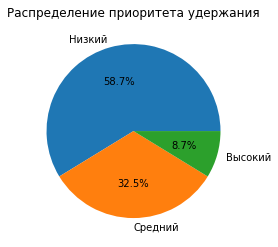

In [50]:
#Рзделяю клиентов по приоритету удержания в зависимости от их сегмента и предсказанного уровня активности
fin_table_w_revenue['Приоритет удержания'] = fin_table_w_revenue.apply(
    lambda row: 'Высокий' if (row['Предсказанные значения'] == 'Снизилась') & (row['Сегмент покупателей'] == 'Высокая прибыльность')
        else 'Средний' if ((row['Предсказанные значения'] == 'Прежний уровень') & (row['Сегмент покупателей'] == 'Высокая прибыльность')) | ((row['Предсказанные значения'] == 'Снизилась') & (row['Сегмент покупателей'] == 'Средняя прибыльность'))
        else 'Низкий',
    axis=1
)
fin_table_w_revenue['Приоритет удержания'].value_counts().plot(kind='pie', autopct='%1.1f%%', ylabel='', title='Распределение приоритета удержания');

**Вывод:** Клиенты были разделены по приоритету удержания на основе их прибыльности и предсказанного уровня активности.

В группу с высоким приоритетом удержания вошли клиенты, приносящие высокий доход, но демонстрирующие снижение активности. Эти пользователи особенно важны для бизнеса, поскольку обладают высокой ценностью, но в данный момент теряют интерес. Для их удержания целесообразно применять персонализированные программы лояльности, эксклюзивные предложения и индивидуальные скидки.

Клиенты со средним приоритетом удержания включают две подгруппы:
– доходных клиентов с прежним уровнем активности,
– а также клиентов со средней прибыльностью, чья активность начала снижаться.
Для первой подгруппы важно поддерживать интерес и мотивацию через VIP-статусы или ранний доступ к новинкам. Вторую подгруппу можно активизировать при помощи ограниченных по времени акций, бонусов за повторные покупки и персональных рекомендаций.

Клиенты с низким приоритетом удержания в настоящий момент не проявляют высокой активности и приносят небольшой доход. Однако и среди них могут быть перспективные пользователи. Их вовлечение можно стимулировать через автоматизированные e-mail-кампании с простыми предложениями, напоминаниями об отложенных товарах, акциями «пригласи друга» или базовыми бонусами за возвращение на платформу.



##  Итоговый вывод

**Задача:**
Интернет-магазин «В один клик» столкнулся с падением активности постоянных клиентов. Поскольку привлечение новых пользователей оказалось неэффективным, было принято решение сосредоточиться на удержании текущих клиентов за счёт персонализации коммуникаций и продуктов. Основная цель проекта — предсказать снижение активности и выделить группы пользователей для приоритетного удержания.

**Этапы анализа:** 
1) Предобработка данных
- Объединены и очищены три исходных датасета, устранены явные и неявные дубликаты.
- Проведена типизация признаков и проверка на пропуски.
- Финальный датасет market_df содержит 1300 записей и 13 признаков, описывающих: каналы коммуникации с клиентами, поведение на сайте, покупательскую активность и предпочтения, клиентские характеристики.

2) Исследовательский анализ
- Целевой признак ("Покупательская активность"):
Снижение активности зафиксировано у ~⅓ клиентов. \
Большинство пользователей — стандартный сервис, согласны на маркетинговые сообщения. 
- Коммуникации и активность:
За 6 месяцев клиентам в среднем поступало 3–6 касаний. \
Время на сайте не подчиняется нормальному распределению (пик ~12.5 мин). \
Выручка сконцентрирована в диапазоне 2 500–8 000 руб, максимум ~5 000.
- Поведение на сайте:
страниц_за_визит и минут_предыдущий_месяц — сильные поведенческие маркеры лояльности. \
Просмотры категорий близки к нормальному распределению, ошибки сервиса — редки.
- Корреляционный анализ выявил:
Сильную связь между выручкой и акционными покупками. \
Признаки времени на сайте и просмотров сильно коррелируют с целевым признаком.

**Модель и интерпретация** \
Для предсказания снижения активности использована модель логистической регрессии.
С помощью SHAP-анализов определены наиболее влиятельные признаки:

Влияют на сохранение активности такие признаки как (SHAP < 0):
- страниц_за_визит
- минут_предыдущий_месяц
- средний_просмотр_категорий_за_визит
Высокие значения по этим параметрам соответствуют лояльным пользователям.

Влияют на снижение активности следующие признаки (SHAP > 0):
- акционные_покупки
- неоплаченные_продукты_штук_квартал
Клиенты, зависящие от скидок или оставляющие товары в корзине, попадают в группу риска. Также отмечен разброс SHAP у акционные_покупки, что указывает на нелинейное поведение.

Малоинформативные признаки:
- популярная_категория
- тип_сервиса
- разрешить сообщать
Данные признаки имеют слабое влияние на модель.

**Бизнес-применение результатов**
1) Стратегия удержания 
- Лояльные пользователи много смотрят, долго на сайте, активны в категориях. Им можно предлагать программы лояльности, ранний доступ к новинкам, персональные подборки.
- Пользователи из группы риска зависят от скидок или не завершают покупки без акций. Для них эффективны персональные акции, email-напоминания об оставленных товарах, ограничения по времени на скидки.

2) Приоритизация клиентов по уровню риска и прибыли
- Высокий:	Клиенты с высокой доходностью, но пониженной активностью. Им стоит предлагать персональные скидки и VIP-кампании.
- Средний:	Умеренно прибыльные клиенты с пониженной активностью. Нужно фокусироваться на поддержании интереса, ограниченных акциях, персональных рекомендациях.
- Низкий: Низко прибыльные клиенты с пониженной активностью. Для их привлечения можно использовать автоматизированные напоминания, базовые бонусы, реферальные акции.